# Notebook 04 — Regularization

Overfitting is the main failure mode for UDEs trained on small or noisy datasets:
the network memorises the training observations and produces a forecast that diverges
almost immediately. This notebook demonstrates four regularization tools:

| Tool | Argument | Effect |
|------|----------|--------|
| L2 weight decay | `weight_decay=` | Shrinks all weights evenly |
| L1 penalty | `lambda_l1=` | Promotes sparse weights |
| Elastic Net | both | Combination of L1 + L2 |
| Dropout | `dropout=` | Randomly drops neurons during training |
| Parameter bounds | `param_bounds=` | Keeps mechanistic params physical |

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.integrate import solve_ivp
import pyUDE as ude

np.random.seed(0)
torch.manual_seed(0)

## 1 — Generate Small, Noisy Lotka-Volterra Data

Only 40 observations with 10% Gaussian noise — a deliberately difficult regime.

In [2]:
def lv_rhs(t, u, alpha=1.0, beta=0.1, delta=0.075, gamma=1.5):
    x, y = u
    return [alpha*x - beta*x*y, delta*x*y - gamma*y]

sol = solve_ivp(lv_rhs, [0, 15], [10.0, 5.0], t_eval=np.linspace(0, 15, 40),
                method='RK45')

noise = 0.10
data = pd.DataFrame({
    'time':     sol.t,
    'prey':     sol.y[0] * (1 + noise * np.random.randn(40)),
    'predator': sol.y[1] * (1 + noise * np.random.randn(40)),
})

# Dense true trajectory for comparison
sol_true = solve_ivp(lv_rhs, [0, 20], [10.0, 5.0],
                     t_eval=np.linspace(0, 20, 400), method='RK45')

train_data, test_data = ude.train_test_split(data, test_fraction=0.2)
print(f'Train: {len(train_data)}  Test: {len(test_data)}')

Train: 32  Test: 8


## 2 — Overfitting Baseline

A large network (`hidden_units=128`) trained without regularization will memorise the
training points and produce a forecast that diverges past the training window.

In [3]:
EPOCHS = 150

model_base = ude.NODE(train_data, hidden_units=64, hidden_layers=2)
model_base.train(loss='derivative_matching', epochs=EPOCHS, verbose=False)
fc_base = model_base.forecast(steps=60)
print('Baseline trained.')

Baseline trained.


## 3 — L2 Weight Decay

`weight_decay` is passed directly to the Adam optimizer and applies L2 regularization
by adding `λ * ||θ||²` to the loss at each step.

In [4]:
model_l2 = ude.NODE(train_data, hidden_units=64, hidden_layers=2)
model_l2.train(loss='derivative_matching', epochs=EPOCHS,
               weight_decay=1e-3, verbose=False)
fc_l2 = model_l2.forecast(steps=60)
print('L2 trained.')

L2 trained.


## 4 — L1 Penalty

`lambda_l1` adds an explicit L1 penalty `λ * Σ|θ|` to the loss. Unlike L2, L1 pushes
individual weights to exactly zero, creating sparse networks.

In [5]:
model_l1 = ude.NODE(train_data, hidden_units=64, hidden_layers=2)
model_l1.train(loss='derivative_matching', epochs=EPOCHS,
               lambda_l1=1e-4, verbose=False)
fc_l1 = model_l1.forecast(steps=60)
print('L1 trained.')

L1 trained.


## 5 — Dropout

`dropout=0.2` randomly zeros 20% of neurons at each training step, preventing
the network from co-adapting to specific patterns in the training data.

In [6]:
model_do = ude.NODE(train_data, hidden_units=64, hidden_layers=2, dropout=0.2)
model_do.train(loss='derivative_matching', epochs=EPOCHS, verbose=False)
fc_do = model_do.forecast(steps=60)
print('Dropout trained.')

Dropout trained.


## 6 — Side-by-Side Forecast Comparison

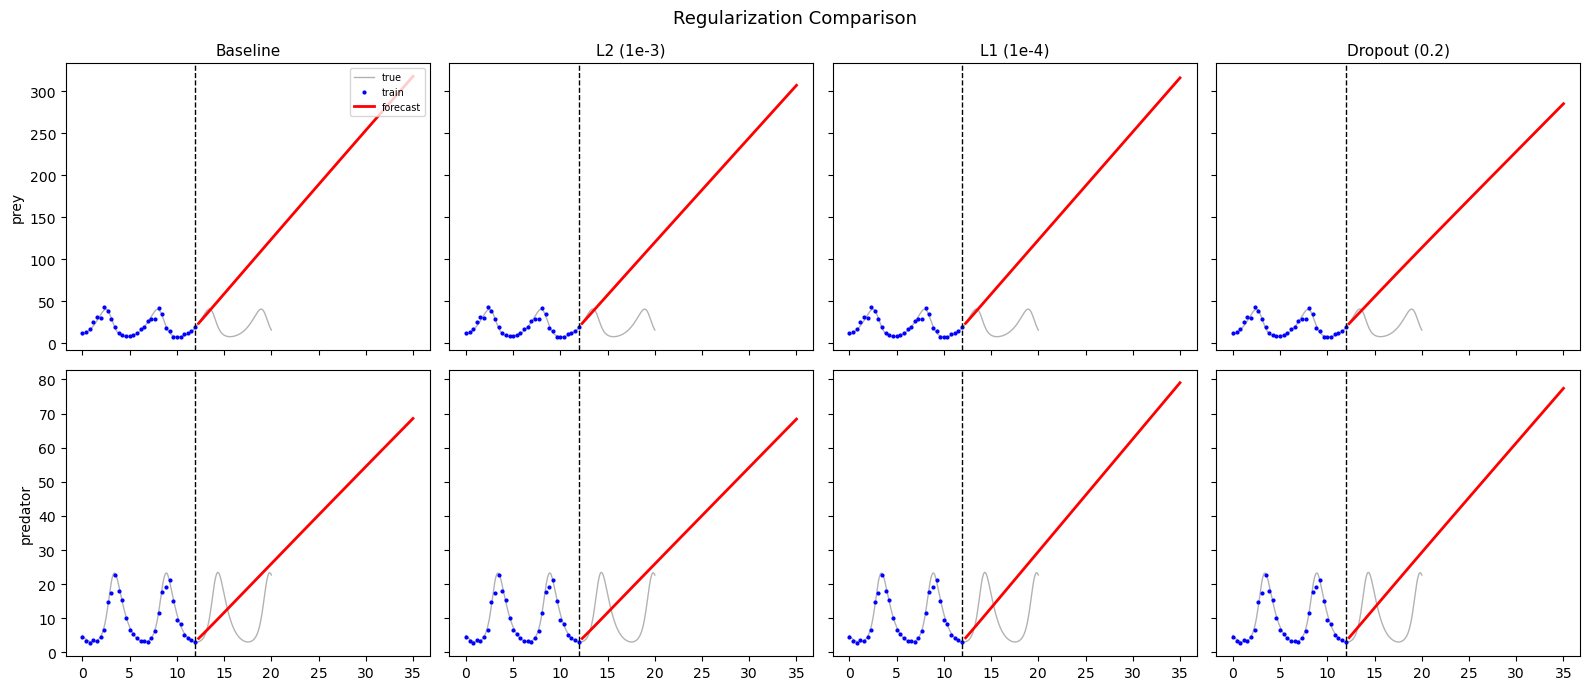

In [7]:
state_cols = ['prey', 'predator']
true_t = sol_true.t

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey='row')
labels = ['Baseline', 'L2 (1e-3)', 'L1 (1e-4)', 'Dropout (0.2)']
forecasts = [fc_base, fc_l2, fc_l1, fc_do]

for col_idx, (label, fc) in enumerate(zip(labels, forecasts)):
    for row_idx, col in enumerate(state_cols):
        ax = axes[row_idx, col_idx]
        ax.plot(true_t, sol_true.y[row_idx], 'k-', alpha=0.3, lw=1, label='true')
        ax.plot(train_data['time'], train_data[col], 'b.', ms=4, label='train')
        ax.plot(fc['time'], fc[col], 'r-', lw=2, label='forecast')
        ax.axvline(train_data['time'].iloc[-1], color='k', ls='--', lw=1)
        if row_idx == 0:
            ax.set_title(label, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(col)

axes[0, 0].legend(fontsize=7, loc='upper right')
plt.suptitle('Regularization Comparison', fontsize=13)
plt.tight_layout(); plt.show()

## 7 — RMSE Comparison on Test Set

In [8]:
from copy import deepcopy

# Compute RMSE for each model on the test window
min_len = len(test_data)
for label, fc in zip(labels, forecasts):
    aligned = fc.iloc[:min_len].reset_index(drop=True)
    r = ude.rmse(test_data[state_cols].reset_index(drop=True),
                 aligned[state_cols])
    print(f'{label:<22}  RMSE mean={r["mean"]:.3f}  prey={r["prey"]:.3f}  pred={r["predator"]:.3f}')

Baseline                RMSE mean=17.714  prey=24.125  pred=6.750
L2 (1e-3)               RMSE mean=17.258  prey=23.448  pred=6.771
L1 (1e-4)               RMSE mean=17.466  prey=23.955  pred=6.023
Dropout (0.2)           RMSE mean=16.323  prey=22.296  pred=5.982


## 8 — `param_bounds` on CustomDerivatives

Mechanistic parameters like growth rates must be positive. Without bounds, gradient
updates can push them negative, making the model physically nonsensical.

In [9]:
def lv_known(u, p, t):
    """Known linear growth / death terms. Predation is learned by the NN."""
    prey, pred = u[0], u[1]
    return torch.stack([
        p['alpha'] * prey,    # prey growth (known structure)
        -p['gamma'] * pred,   # predator death (known structure)
    ])

# Without bounds — alpha and gamma can go negative
model_no_bounds = ude.CustomDerivatives(
    train_data, lv_known,
    init_params={'alpha': 0.5, 'gamma': 1.0},
)
model_no_bounds.train(loss='derivative_matching', epochs=300, verbose=False)
print('No bounds — learned params:', model_no_bounds.get_params())

# With bounds — both params stay >= 0
model_bounded = ude.CustomDerivatives(
    train_data, lv_known,
    init_params={'alpha': 0.5, 'gamma': 1.0},
    param_bounds={'alpha': (0.0, None), 'gamma': (0.0, None)},
)
model_bounded.train(loss='derivative_matching', epochs=300, verbose=False)
print('Bounded  — learned params:', model_bounded.get_params())

No bounds — learned params: {'alpha': 0.20338665300957146, 'gamma': 0.6975427456767127}


Bounded  — learned params: {'alpha': 0.20559124615889376, 'gamma': 0.6951311341403718}


## Key Takeaways

- **L2** (`weight_decay`) shrinks weights uniformly — good all-round regularizer.
- **L1** (`lambda_l1`) promotes sparsity — useful when only a few terms drive dynamics.
- **Elastic Net** = L1 + L2 simultaneously.
- **Dropout** (`dropout=`) works well with small datasets; default `0.2` is a safe start.
- **`param_bounds`** is essential for `CustomDerivatives` when parameters have physical
  meaning — it prevents the optimizer from pushing them into physically impossible ranges.
- All regularizers are backward-compatible: default values (`0.0` / `None`) disable them.